<a href="https://colab.research.google.com/github/krishhhna7/Mapping-Chronic-Disease-Progression-with-Neo4j/blob/main/Lectutorial1Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMPSCI 714 - Lectutorial 1 - Data basics

## Coding time 1

First of all, let's import some useful modules we will use in this session.
- <a href="https://matplotlib.org/stable/api/pyplot_summary.html"><code>sklearn</code></a> is a machine learning library.
- <a href="https://scikit-learn.org/stable/datasets.html"><code>sklearn.datasets</code></a> contains a few toy datasets and helper functions to fetch larger datasets.
- <a href="https://pandas.pydata.org/docs/"><code>numpy</code></a> is a scientific computing library.
- <a href="https://pandas.pydata.org/docs/"><code>pandas</code></a> is a data analysis and manipulation library.
- <a href="https://matplotlib.org/stable/api/pyplot_summary.html"><code>matplotlib.pyplot</code></a> contains a collection of functions to create figures and plot data.
- <a href="https://matplotlib.org/stable/api/pyplot_summary.html"><code>pathlib</code></a> contains a collection of classes to run operations with file systems paths and provide methods to do system calls on path objects.
- <a href="https://matplotlib.org/stable/api/pyplot_summary.html"><code>tarfile</code></a> contains functions to read and write tar archive files.
- <a href="https://matplotlib.org/stable/api/pyplot_summary.html"><code>urllib.request</code></a> contains functions and classes to work with URLs.

In [1]:
import sklearn
from sklearn.datasets import fetch_california_housing
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tarfile
import urllib.request

Let's load the california housing dataset as a <a href="https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html"><code>pandas.DataFrame</code></a> using the dedicated Scikit-Learn helper function, with the <code>as_frame</code> argument set to <code>True</code>.

In [2]:
df_cali_housing_dataset = fetch_california_housing(as_frame = True).frame

### Basic exploration

We can now do some basic data exploration. Try to run:
- <code>df_cali_housing_dataset.head()</code>
- <code>df_cali_housing_dataset.info()</code>
- <code>df_cali_housing_dataset.describe()</code>

What useful information can you get from each output?

In [3]:
# Todo

Try next to:
- Diplay the names of the dataset's features.
- Display the features' values of the 20th instance of the dataset.
- Display the features' values of the 20th instance of the dataset, without the Median house value (which is actually the target).

In [4]:
# Todo

### Visualising the data

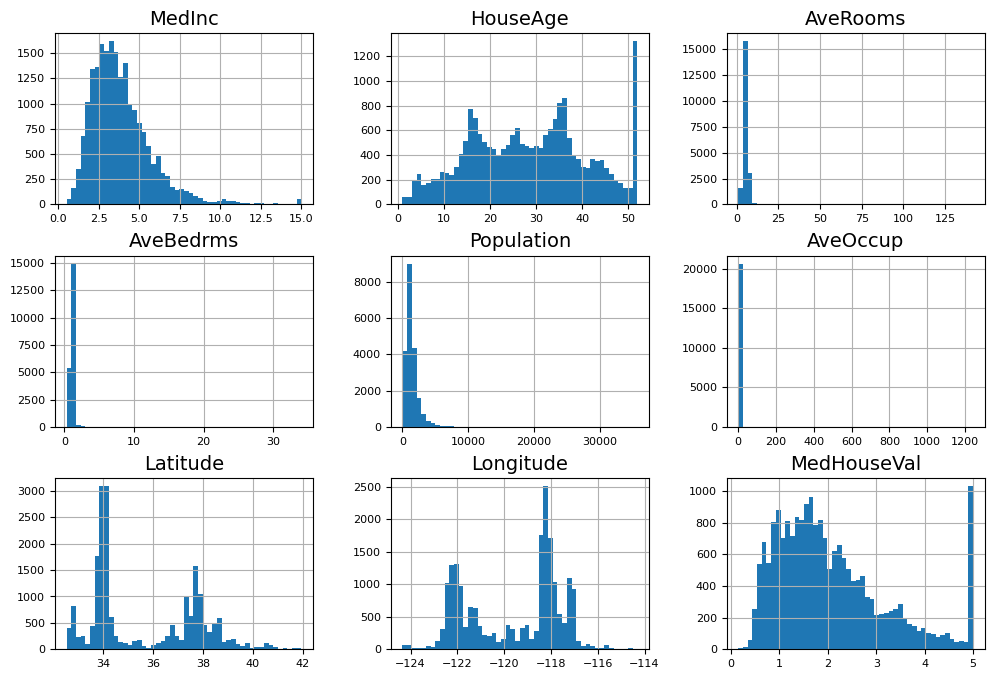

In [5]:
# If needed, you can change the font sizes with the following 5 lines.
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)

# Code to generate and plot the histograms for the numerical attributes
df_cali_housing_dataset.hist(bins=50, figsize=(12, 8))
plt.show()

### Loading data from a CSV file

You can find below a helper function that can be used to download a file from a distance repository, and load it as a Pandas DataFrame.

Identify the instruction which is reading the CSV file.

In [6]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

df_housing_from_csv = load_housing_data()

/tmp/ipykernel_506/2586949727.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


Perform a basic exploration of the dataset to see the differences with the one loaded from Scikit-Learn.

In [7]:
# Todo

### Loading data from OpenML

Let's load a dataset from OpenML repository using the <code>sklearn.dataset.fetch_openml()</code> function.

In [8]:
# Todo

## Coding time 2

In [9]:
from sklearn.model_selection import train_test_split
from pandas.plotting import scatter_matrix

## Splitting the data in train and test sets

Before exploring the data further, you should set a portion of it aside at this stage. This is called a test set, and it will be used for model evaluation and validation. It is important to set it aside now, because you should not look at your test set at all before the final evaluation of your model. We will discuss this further in the lectures and tutorials next week.
When creating a test set, you can choose one of the two approaches depending on the size of your dataset.

- If your dataset is **large enough** (especially relative to the number of attributes): sample purely **randomly** from the dataset.
- If your dataset is **not large** and you know that an attribute has a **high influence** on the target prediction: use **stratified sampling** to avoid introducing a significant sampling bias. This ensures that your test set has a similar distribution of values for each attribute as the full dataset. Else, the estimated importance of a category of values for a specific attribute might be biased.


We will use the housing data previously loaded from the csv file fetched from the github repository. Let's visualise the attributes.

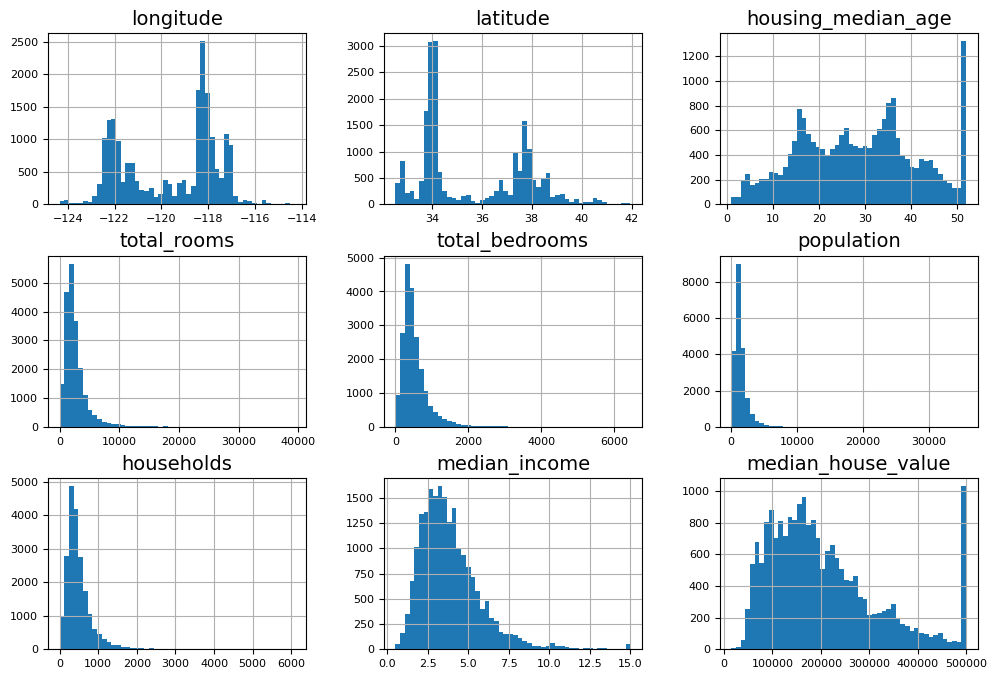

In [10]:
# Code to generate and plot the histograms for the numerical attributes
df_housing_from_csv.hist(bins=50, figsize=(12, 8))
plt.show()

The median income looks quite correlated with the median house value (target), so we might want to use stratified sampling to make sure we do not create imbalance in the training and test data.

To that end, we first want to "bin" the values of the <code>median_income</code> attribute, to create categories of income.
Let's create a new attribute to the dataset, <code>income_cat</code>, splitting the values of <code>median_income</code> in 5 bins.

In [11]:
df_housing_from_csv["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

NameError: name 'housing' is not defined

In [ ]:
df_housing_from_csv["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

We can then use the <code>train_test_split</code> function from the <code>sklearn.model_selection</code> module to perform the train/test set split. We need to specify the test set size (here 20% of the total dataset), and the attribute we want to use as reference for the stratify sampling process (the income category).

Notice that we also specify a random state number. This is to ensure that we always get the same instances in the test set when we run the train/test split several times.


In [ ]:
strat_train_set, strat_test_set = train_test_split(
    df_housing_from_csv, test_size=0.2, stratify=df_housing_from_csv["income_cat"], random_state=42)

Let's visualise the effect of the startified sampling vs random sampling in that case.

In [ ]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

# TODO: Uncomment and fill the following instruction to split trqin qnd test sets randomly (without stratify sampling)
# train_set, test_set = train_test_split()

compare_props = pd.DataFrame({
    "Overall %": income_cat_proportions(df_housing_from_csv),
    "Stratified Train %": income_cat_proportions(strat_train_set),
    "Stratified Test %": income_cat_proportions(strat_test_set),
    "Random Train %": income_cat_proportions(test_set),
    "Random Test %": income_cat_proportions(test_set),
}).sort_index()
compare_props.index.name = "Income Category"
compare_props["Strat. Error Train %"] = (compare_props["Stratified Train %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Strat. Error Test %"] = (compare_props["Stratified Test %"] /
                                   compare_props["Overall %"] - 1)
compare_props["Rand. Error Train %"] = (compare_props["Random Train %"] /
                                  compare_props["Overall %"] - 1)
compare_props["Rand. Error Test %"] = (compare_props["Random Test %"] /
                                  compare_props["Overall %"] - 1)
(compare_props * 100).round(2)

What is the effect of stratified sampling compared to random sampling here?

Before moving on, we need to remove the attribute income_cat that we created for the stratified sampling.

In [ ]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

### Data exploration

We can process with more sophisticated data exploration **on the training set** to get more insights about the dataset.
If your dataset is too large, you can sample an exploration set.

Let's firt make a copy of the training set as we might make transformations to it during the exploration.

In [ ]:
explo_housing_data = strat_train_set.copy() # Avoid explo_housing_data = strat_train_set as this does not make a seperate copy of the data

#### Visualisation of geographic data

A first interesting visualisation would be to display a scatterplot of the geographical position of all the districts, using the longitude and latitude attributs.
Tips: try to use the Pandas.DataFrame <code>plot()</code> method.

In [ ]:
# TODO

Does the shape remind you of anything? (if not, you might want to switch the x and y coordinates)

Play around with the options for the visualisation. E.g., set the <code>alpha</code> parameter (it regulates the transparency of the plot) so that you have a better idea of the density of points in the plot. Where are most districts situated?

In the more complete Notebook, you can play around with this visualisation by adding the population and median house price information.

#### Correlation

Machine learning algorithms are trying to build models by learning patterns in data. These patterns are linked to correlations between attributes and targets.
So, let's next have a look at the correlation between attributes, by calculating the standard correlation coefficent, or Pearson's correlation coefficient.

In [ ]:
corr_matrix = explo_housing_data.corr(numeric_only=True) #Need to set numeric_only to True with Pandas 2.0
corr_matrix["median_house_value"].sort_values(ascending=False)

You can also visualise correlations by using scatter plots.

Try to use the <code>scatter_matrix</code> function imported earlier to plot the correlations between the media house value and the 3 most correlated attributes from the previous list.

In [ ]:
# TODO

Finally, display a scatter plot of the median house value, and the most correlated attribute, the median income.

In [ ]:
# TODO

## Coding time 3

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn import set_config
from sklearn.compose import ColumnTransformer
from sklearn.compose import make_column_selector, make_column_transformer

### Data cleaning

First let's create a copy of the original training set, with labels stored in a seperate variable.  

In [ ]:
housing_data = strat_train_set.drop("median_house_value", axis=1) # Creates a copy of the dataset without the median_house_value attribute, without modifying strat_train_set
housing_data_labels = strat_train_set["median_house_value"].copy()

#### Missing values

Run <code>housing_data.info()</code> and observe the number of non-null values for each attribute. What do you notice?


In [ ]:
# TODO

There are 3 ways to deal with missing values:
1. Remove the instances with missing attribute value
2. Remove the whole attribute
3. Impute the missing value, i.e. replace it with some value such as zero, the mean, the median, etc.

You may choose on approach or another depending on your problem, your data, the reason the values are missing, etc. Each approach comes with its own caveats. Removing instances or attributes might result in potentially loosing some valuable information (especially if you have a small dataset with a small number of attributes), while imputing values might introduce some noise to your data.  

You can directly use the Pandas DataFrame's `dropna()`, `drop()` and `fillna()` methods to perform repectively instance removal, attribute removal and imputation.  
E.g.:  
```python
housing_data.dropna(subset=["total_bedrooms"], inplace=True)    # option 1

housing_data.drop("total_bedrooms", axis=1)       # option 2

median = housing_data["total_bedrooms"].median()  # option 3
housing_data["total_bedrooms"].fillna(median, inplace=True)
```

For option 3, you can also use the Scikit-Learn <code>SimpleImputer</code> class. This is a more sophisticated approach which will allow us to train an imputer able to impute values not only for the training set, but also for the validation set, test set, and for any new data instance fed to the model.

In [ ]:
imputer = SimpleImputer(strategy="median")

If using the median approach, you first need to get rude of non-numerical attributes.

In [ ]:
housing_data_num = housing_data.select_dtypes(include=[np.number])

Use the <code>fit</code> method to train the imputer, i.e., calculate the median for each attribute in this case.

In [ ]:
imputer.fit(housing_data_num)

The median value for each attribute is stored in the `statistics_` field of the `imputer` instance.

In [ ]:
# TODO

In [ ]:
imputer.statistics_

You can now impute the missing values by using the `tranform()` method on the `imputer` instance:

In [ ]:
X = imputer.transform(housing_data_num)

Check the type of the object returned by the `tranform()` method. Is it still a Panda DataFrame?  

In [ ]:
# TODO

You can run the following code to wrap `X` back to a Panda DataFrame. Take a little bit of time to understand this instruction, as you are likely to use this kind of wrapping regularly when manipulating data.

In [ ]:
housing_data_tr = pd.DataFrame(X, columns=housing_data_num.columns,
                          index=housing_data_num.index)

Compare the 5 first rows containing missing values before and after imputing values.

In [ ]:
# TODO

Note that you can choose the replace the missing values with other strategies. To do so, you can change the `strategy` parameter passed to the `imputer` instance when you create it, e.g.:
- With the mean value of the attribute (`strategy="mean"`)
- With the most frequent value of the attribute (`strategy="most_frequent"`)
- With a constant value (`strategy="constant", fill_value=...`)

The two last strategies work also for non-numerical attributes.

#### Removing outliers

Detecting outliers is not always an easy problem, and there are several possible approaches and methods you can use. One popular method is the isolation forest algorithm, which is an unsupervised technique using binary trees to detect outliers. Use the `IsolationForest` class from the `sklearn.ensemble` module to perfom outlier detection on your data.  
Run the following cell to perform the outlier detection:

In [ ]:
isolation_forest = IsolationForest(random_state=42)
outlier_pred = isolation_forest.fit_predict(X)

Notice that we pass `X` as parameter to the IsolationForest `fit_predict()` method. This is because this method takes an array-like parameter, so it would generate an error if we try to pass a Pandas DataFrame.  

Inspect the output of the detection and the shape of the returned object.

In [ ]:
# TODO

Complete the following code to drop the outliers predicted by the isolation forest.

In [ ]:
# TODO
# housing_data_no = housing_data.iloc[outlier_pred == ?]
# housing_data_no_labels = housing_data_labels_num.iloc[outlier_pred == ?]

Using similar instructions, you can also store the outliers.

In [ ]:
# TODO
# outliers = ...
# outliers_labels = ...

Run the next cell to visualise the data after removing the outliers (circle markers) and the outliers on the same scatter plot:

In [ ]:
plt.scatter(x=housing_data_no["median_income"].tolist(), y=housing_data_no_labels.to_list(), alpha = 0.2, marker="o")
plt.scatter(x=outliers["median_income"].tolist(), y=outliers_labels.to_list(), alpha = 0.2 , marker="x")
plt.show()

Modify the previous cell to visualise other attributes against the target. Some outliers might make more visual sense if you look at the data from a different "angle".

### Data pre-processing

After cleaning your data, you need to perform a few more transformation steps so that it is ready to be used by an algorithm to learn a model. These steps are typically called data pre-processing.

In the context of this tutorial, two main pre-processing steps are needed:
1. Transforming text/categorical attributes to numerical attributes
2. Scaling and transforming the data

Depending on the task at hand, you might need to include additional pre-processing steps. For example, if you have a classification task with unbalanced data (i.e., one or more classes are over/under represented in the dataset), you may want to include some preprocessing steps to mitigate this.

#### Converting text and categorical attributes to numerical values

Look at the values of the `ocean_proximity` attribute in the `housing_data` dataset.

In [ ]:
# TODO

Since most machine learning algorithms work only with numerical values for the attributes, you usually need to convert text categories to numbers.  
The most straighforward way to do this is to convert each different text category to a different number. This called *ordinal encoding*. You can use the Scikit Learn's `OrdinalEncoder` to do so:

In [ ]:
housing_data_cat = housing_data[["ocean_proximity"]]
ordinal_encoder = OrdinalEncoder()
housing_data_cat_encoded = ordinal_encoder.fit_transform(housing_data_cat)

Display the 8 first values of the attribute before and after transformation.

In [ ]:
# TODO

What is the problem with this encoding in this specific case?

A common fix is to encode the categories with a group of binary attributes. Each binary attribute correspond to a category and is set to 1 if the instance is part of this category, 0 otherwise. This is called *one-hot encoding*, because for each instance only one attribute is set to 1 (hot), while the others are set to 0. The new attributes are sometimes called *dummy* attributes.  
You can use the Scikit Learn's `OnHotEncoder` class to convert categorical values into one-hot vectors:

In [ ]:
cat_encoder = OneHotEncoder()
housing_data_cat_1hot = cat_encoder.fit_transform(housing_data_cat)

Display the 8 first elements of the attribute after transformation.

The `to_array()` method will be useful to convert the output sparse matrix in a NumPy array.

In [ ]:
# TODO

Alternatively, you can also set `sparse_output=False` when creating the `OneHotEncoder` instance for the `transform` and `fit_transform` methods to directly return a regular NumPy array:
```Python
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
```

You can then use the trained encoder to encode categorical attributes for test instances, with the same number of categories seen in the training:

In [ ]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})
cat_encoder.transform(df_test).toarray()

Try to encode the following test intance with the trained one-hot encoder.

What do you notice?

In [ ]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})
# TODO

To deal with unknown categories, you can set the `handle_unknown` field of the encode to `ignore` and then perform the encoding.

In [ ]:
cat_encoder.handle_unknown = "ignore"
# TODO

Note that if a categorical attribute has a lot of categories, using one-hot encoding will results in a very large number of new binary, *dummy*, attributes. This might end up slowing down training and degrade performances. If that is the case, one option can be to design a numerical attribute to replace the categorical attribute, containing the same information. For example, the `ocean_proximity` could be replaced by a numerical attribute containing the distance to the ocean. Alternatively, you can use one of the encoders provided by the Category Encoder package (https://contrib.scikit-learn.org/category_encoders/).  

In the case of neural networks, which we will focus on in the following tutorials, categorical attributes can be replaced with low-dimensional vectors, learned through the training phase. These vectors are called *embeddings*. These embeddings are particularly used in Natural Language Processing as the data is mostly textual.


#### Scaling the data

Scaling is one of the most important pre-processing steps, as most machine learning algorithms do not perform well if the numerical attributes have very different scales.
This is the case for the housing dataset we are using here. For example, the total **number of rooms** ranges from about **6 to 39 320**, while the **median income** only ranges from **0 to 15**.

You can see this with the visualisation of the dataset or the DataFrame `describe()` method.


Without scaling in the pre-processing phase, most machine learning algorithms will ignore the median income when learning the model, and focus more on the total number of room. This is because it would consider that the variables in the median income are too small compared to the ones in the total number of rooms, and therefore not useful to describe the patterns.

As with all pre-processing transformations, scaler should be trained/fitted on the training data only. Once trained, they can be used to transform the validation set, test set and new data points.

There are two main approaches to get the attributes to have to same scale:
- Min-max scaling (also called normalisation)
  
  $\Large x_{scaled}=\frac{x - x_{min}}{x_{max}-x_{min}}$
  
- Standardisation
  
  $\Large x_{standard}=\frac{x - \mu}{\sigma}$

  



In [ ]:
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_data_num_min_max_scaled = min_max_scaler.fit_transform(housing_data_num)

The Scikit-Learn `MinMaxScaler` `fit_transform()` method returns a NumPy array that we can convert back to a Pandas DataFrame, and plot the attributes to see the effect of the min_max_normalisation (look at the x axis):

In [ ]:
df_housing_data_num_min_max_scaled = pd.DataFrame(housing_data_num_min_max_scaled,
                         columns=min_max_scaler.get_feature_names_out(),
                         index=housing_data_num.index)
df_housing_data_num_min_max_scaled.hist(bins=50, figsize=(12, 8))
plt.show()

Is min-max scaling dealing well with outliers?

Let's try standardisation now.

In [ ]:
std_scaler = StandardScaler()
housing_data_num_std_scaled = std_scaler.fit_transform(housing_data_num)

In [ ]:
df_housing_data_num_std_scaled = pd.DataFrame(housing_data_num_std_scaled,
                         columns=std_scaler.get_feature_names_out(),
                         index=housing_data_num.index)
df_housing_data_num_std_scaled.hist(bins=50, figsize=(12, 8))
plt.show()

Another type of common preprocessing is to apply distribution transformations. Most machine learning algorithms works best with data following a Gaussian distribution, also known as Normal distribution. Therefore it is usually important to transform attributes so that their distribution becomes close to a Gaussian distribution.

You can learn more about this in the extra material Notebook.

### Transformation pipelines

We have seen a number of pre-processing steps to transform the data in a form more adapted to train a model.
We will now see how we can bring all of these together in a transformation pipeline.

Scikit-Learn provides a `Pipeline` class to build a sequence of transformations. You can see in the next cell a simple pipeline for numerical attributes, which first imputes missing values and then scales the input attributes:

In [ ]:
num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("standardize", StandardScaler()),
])
num_pipeline

You can also use the `make_pipeline()` function for a lighter syntax, and if you do not wish to name each transformer in your pipeline (standard names will be given to each of them, using the corresponding transformer's class name):

In [ ]:
num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

You can also set the visualisation of the pipeline to a simple diagram if you do not want to use the interactive visualisation (you can set it back to the diagram display with `display='diagram'`):

In [ ]:
set_config(display='text')
num_pipeline

You can use the `fit_transform()` method to apply this pipeline to the numerical attributes of the housing dataset.

In [ ]:
# TODO
# housing_data_num_prepared = ...

In [ ]:
df_housing_data_num_prepared = pd.DataFrame(housing_data_num_prepared,
                         columns=num_pipeline.get_feature_names_out(),
                         index=housing_data_num.index)
df_housing_data_num_prepared.hist(bins=50, figsize=(12, 8))
plt.show()

In [ ]:
df_housing_data_num_prepared.info()

Let's now handle both numerical and categorical attributes i nthe same pipeline using the `ColumnTransformer` class.

In [ ]:
num_attribs = ["longitude", "latitude", "housing_median_age", "total_rooms",
               "total_bedrooms", "population", "households", "median_income"]
cat_attribs = ["ocean_proximity"]

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs),
])

In [ ]:
preprocessing

Instead of manually creating lists of attributes for each part of the pipeline, you can use the `make_column_selector` function to automatically select the attributes of a specified type. Similarly as `make_pipeline` previously, you can also use the `make_column_transformer` function to avoid naming the transformers yourself when defining a `ColumnTransformer`. The code in the next cell creates a `ColumnTransformer` by applying our `num_pipeline` to selected attributes with data type `np.number`, and our `cat_pipeline` to selected attributes with data type `object` (which is used for text in Pandas).

In [ ]:
preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include=object)),
)

Finally, you can apply the pipeline to the dataset with both numeraical and categorical attributes, and visualise the result as we just did for the numerical attribute pipeline.

In [ ]:
# TODO
# housing_data_prepared = ...
# Convert to DataFrame and display histograms

This is it for this session!
The extra material Notebook presents a pipeline with a few more pre-processing. Feel free to have a look at it.

<img src="attachment:6708ffd9-c50b-4698-b4a7-572337c9d67c.png" width="375" height="225">

<img src="attachment:6708ffd9-c50b-4698-b4a7-572337c9d67c.png" width="375" height="225">